# # ML Phishing Email Detection + Security Dashboard


## Introduction

Phishing is one of the most common cybersecurity threats where attackers use fake emails to trick users into clicking malicious links, sharing passwords, downloading malware, or revealing sensitive information.

In this project, the goal is to build a machine learning model that can classify email messages as either **Legitimate** or **Phishing** based on the text content of the email.

The project uses a text classification approach. Since email messages are written in natural language, the text must first be converted into numerical features before it can be used by a machine learning model. For this, TF-IDF vectorization is used.

A Logistic Regression model is trained to classify emails. The model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. After training, the model will be saved and later used inside a Streamlit web application.

The final goal is not only to train a machine learning model, but also to build a practical cybersecurity tool that can:
- Predict whether an email is phishing or legitimate
- Show a confidence score
- Identify suspicious indicators
- Assign a risk level
- Log predictions
- Display results in a security dashboard

This project combines machine learning, cybersecurity, phishing awareness, text classification, and security reporting.

## Project Objectives

The main objectives of this project are:

1. Create or load a phishing email dataset.
2. Clean and prepare the email text data.
3. Convert email text into numerical features using TF-IDF.
4. Train a machine learning classification model.
5. Evaluate the model using classification metrics.
6. Test the model with sample phishing and legitimate emails.
7. Save the trained model and vectorizer.
8. Build a Streamlit app for real-time email classification.
9. Add risk scoring, suspicious indicator detection, and prediction logging.
10. Create a security dashboard to summarize detection results.

## Problem Statement

Organizations receive many emails every day, and some of these emails may be phishing attempts. Manual review of every email is time-consuming and may lead to missed threats.

The problem is to build a machine learning model that can analyze email text and classify it as either:

- Legitimate
- Phishing

This can help support cybersecurity teams by flagging suspicious emails for review.

## Project Workflow

The project will be completed in the following steps:

1. Import required libraries
2. Create or load the dataset
3. Explore the dataset
4. Preprocess the text data
5. Split the dataset into training and testing sets
6. Convert text into numerical features using TF-IDF
7. Train a machine learning model
8. Evaluate model performance
9. Test the model with custom email examples
10. Save the model and vectorizer
11. Build the Streamlit application
12. Add prediction logging and dashboard
13. Document the project on GitHub

In [14]:
##  Import Required Libraries
# Data handling
import pandas as pd
import numpy as np

# Text processing and machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Model saving
import joblib

# Visualization
import matplotlib.pyplot as plt

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
 

Libraries imported successfully.


In [15]:
## Create or Load the Dataset
# Create a small phishing email dataset

data = {
    "email_text": [
        # Legitimate emails
        "Your assignment feedback is now available on the student portal.",
        "The library will be closed on Friday due to maintenance.",
        "Please attend the cybersecurity seminar scheduled for Monday.",
        "Your tuition receipt has been uploaded to your college account.",
        "The college cafeteria menu has been updated for this week.",
        "Your professor has shared lecture notes for the AI class.",
        "Reminder: Your student ID card is ready for pickup.",
        "The IT department has scheduled network maintenance tonight.",
        "Your course registration was completed successfully.",
        "Please check the academic calendar for upcoming exam dates.",
        "The student services office will be open from 9 AM to 5 PM.",
        "Your scholarship application has been received.",
        "The college career fair will be held next Wednesday.",
        "Your password was changed successfully as requested.",
        "Please submit your project report before the deadline.",
        "The finance office has confirmed your payment.",
        "Your meeting with the academic advisor is confirmed.",
        "The campus gym schedule has been updated.",
        "Your attendance record is available in the student portal.",
        "The cybersecurity club meeting will start at 4 PM.",

        # Phishing emails
        "Urgent! Your account has been locked. Click this link to verify your password.",
        "Your mailbox storage is full. Login immediately to avoid account suspension.",
        "Congratulations! You have won a gift card. Click here to claim your prize.",
        "Security alert: unusual login detected. Enter your username and password now.",
        "Your bank account will be suspended unless you verify your details immediately.",
        "Click this link to reset your account or your access will be disabled.",
        "You have received a confidential payment. Open the attachment to view details.",
        "Important notice: update your billing information to prevent service interruption.",
        "Your student account has been compromised. Confirm your password urgently.",
        "Claim your free laptop now by entering your college login credentials.",
        "Final warning: your account will be deleted unless you verify now.",
        "You are eligible for a refund. Submit your banking details immediately.",
        "Open this attachment to view your secure document.",
        "Your email access expires today. Login using the link below.",
        "Suspicious activity detected. Provide your password to restore access.",
        "You have won a scholarship. Pay a small processing fee to claim it.",
        "Verify your identity now to avoid losing access to your account.",
        "Your package delivery failed. Click the link to reschedule and pay a fee.",
        "Immediate action required: confirm your login details within 24 hours.",
        "Your account is on hold. Enter your credentials to reactivate it."
    ],
    "label": [
        # 0 = Legitimate
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

        # 1 = Phishing
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

# Save dataset as CSV file
df.to_csv("phishing_dataset.csv", index=False)

print("phishing_dataset.csv created successfully.")
df.head()


phishing_dataset.csv created successfully.


,email_text,label
0,Your assignment feedback is now available on t...,0
1,The library will be closed on Friday due to ma...,0
2,Please attend the cybersecurity seminar schedu...,0
3,Your tuition receipt has been uploaded to your...,0
4,The college cafeteria menu has been updated fo...,0


In [16]:
# Load dataset from CSV file

df = pd.read_csv("phishing_dataset.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,email_text,label
0,Your assignment feedback is now available on t...,0
1,The library will be closed on Friday due to ma...,0
2,Please attend the cybersecurity seminar schedu...,0
3,Your tuition receipt has been uploaded to your...,0
4,The college cafeteria menu has been updated fo...,0


In [17]:
# Check dataset size
print("Dataset shape:", df.shape)

# Show first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Show last 5 rows
print("\nLast 5 rows:")
display(df.tail())

# Check label distribution
print("\nLabel distribution:")
print(df["label"].value_counts())

# Add readable label names
df["label_name"] = df["label"].map({
    0: "Legitimate",
    1: "Phishing"
})

print("\nReadable label distribution:")
print(df["label_name"].value_counts())

Dataset shape: (40, 2)

First 5 rows:


,email_text,label
0,Your assignment feedback is now available on t...,0
1,The library will be closed on Friday due to ma...,0
2,Please attend the cybersecurity seminar schedu...,0
3,Your tuition receipt has been uploaded to your...,0
4,The college cafeteria menu has been updated fo...,0



Last 5 rows:


,email_text,label
35,You have won a scholarship. Pay a small proces...,1
36,Verify your identity now to avoid losing acces...,1
37,Your package delivery failed. Click the link t...,1
38,Immediate action required: confirm your login ...,1
39,Your account is on hold. Enter your credential...,1



Label distribution:
label
0    20
1    20
Name: count, dtype: int64

Readable label distribution:
label_name
Legitimate    20
Phishing      20
Name: count, dtype: int64


In [18]:
# Data Cleaning and Preprocessing
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Check duplicate rows before cleaning
print("\nDuplicate rows before cleaning:")
print(df.duplicated().sum())

# Remove missing values and duplicate rows
df = df.dropna()
df = df.drop_duplicates()

# Clean email text
# Convert text to lowercase and remove extra spaces
df["email_text"] = df["email_text"].str.lower().str.strip()

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Check duplicate rows after cleaning
print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

# Show cleaned data
df.head()

Missing values before cleaning:
email_text    0
label         0
label_name    0
dtype: int64

Duplicate rows before cleaning:
0

Missing values after cleaning:
email_text    0
label         0
label_name    0
dtype: int64

Duplicate rows after cleaning:
0


,email_text,label,label_name
0,your assignment feedback is now available on t...,0,Legitimate
1,the library will be closed on friday due to ma...,0,Legitimate
2,please attend the cybersecurity seminar schedu...,0,Legitimate
3,your tuition receipt has been uploaded to your...,0,Legitimate
4,the college cafeteria menu has been updated fo...,0,Legitimate


In [19]:
# Split Data into Training and Testing Sets
# Define features and target

X = df["email_text"]
y = df["label"]

# Split the data into training and testing sets
# test_size=0.25 means 25% test data and 75% training data
# stratify=y keeps the phishing/legitimate balance similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 30
Testing samples: 10

Training label distribution:
label
1    15
0    15
Name: count, dtype: int64

Testing label distribution:
label
0    5
1    5
Name: count, dtype: int64


In [20]:
# Text Vectorization using TF-IDF

# Convert email text into numerical features using TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

# Fit the vectorizer on training data and transform training emails
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test emails using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed.")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF vectorization completed.
Training TF-IDF shape: (30, 127)
Testing TF-IDF shape: (10, 127)


In [21]:
# Train a Logistic Regression model

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [22]:
# Test with Custom Email Examples

# Test the model with custom email examples

custom_emails = [
    "Your assignment feedback is available on the student portal.",
    "Urgent! Your account has been locked. Click this link to verify your password.",
    "Please attend your academic advising appointment tomorrow at 10 AM.",
    "Congratulations! You have won a free gift card. Enter your login details to claim it.",
    "The library will be closed on Friday due to scheduled maintenance."
]

# Convert custom emails using the same TF-IDF vectorizer
custom_emails_tfidf = vectorizer.transform(custom_emails)

# Predict using the trained model
custom_predictions = model.predict(custom_emails_tfidf)

# Get prediction probabilities
custom_probabilities = model.predict_proba(custom_emails_tfidf)

# Display results
for email, prediction, probability in zip(custom_emails, custom_predictions, custom_probabilities):
    label = "Phishing" if prediction == 1 else "Legitimate"
    confidence = max(probability) * 100

    print("Email:", email)
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 80)

Email: Your assignment feedback is available on the student portal.
Prediction: Legitimate
Confidence: 64.88 %
--------------------------------------------------------------------------------
Email: Urgent! Your account has been locked. Click this link to verify your password.
Prediction: Phishing
Confidence: 63.62 %
--------------------------------------------------------------------------------
Email: Please attend your academic advising appointment tomorrow at 10 AM.
Prediction: Legitimate
Confidence: 59.94 %
--------------------------------------------------------------------------------
Email: Congratulations! You have won a free gift card. Enter your login details to claim it.
Prediction: Phishing
Confidence: 66.64 %
--------------------------------------------------------------------------------
Email: The library will be closed on Friday due to scheduled maintenance.
Prediction: Legitimate
Confidence: 62.11 %
---------------------------------------------------------------------

In [23]:
# Save the trained model and TF-IDF vectorizer

joblib.dump(model, "phishing_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


##  Evaluate the Model

In this step, the trained Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix. These metrics help measure how well the model detects phishing and legitimate emails.

In [25]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy:", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

Model Evaluation Results
------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         5
    Phishing       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Confusion Matrix:
[[5 0]
 [0 5]]


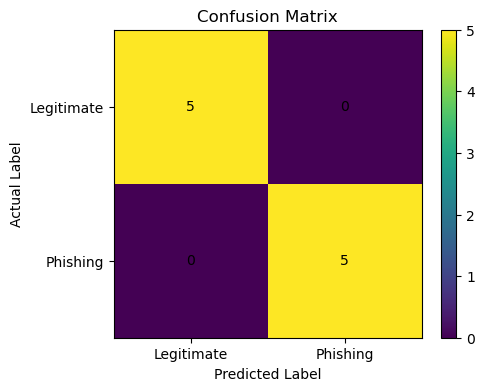

In [26]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.yticks([0, 1], ["Legitimate", "Phishing"])

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.colorbar()
plt.show()

### Confusion Matrix Explanation

The confusion matrix shows that the model correctly classified all 10 test emails.

- 5 legitimate emails were correctly predicted as legitimate.
- 5 phishing emails were correctly predicted as phishing.
- There were 0 false positives.
- There were 0 false negatives.

This means the model performed perfectly on the small test dataset. However, because the dataset is small, the result should not be considered enough for real-world deployment. A larger and more diverse phishing email dataset would be needed to properly validate the model.

##  Test with Custom Email Examples

In this step, the trained model is tested using manually written email examples. This helps check how the model behaves with realistic phishing and legitimate email messages outside the original dataset.

In [27]:
# Test the model with custom email examples

custom_emails = [
    "Your assignment feedback is available on the student portal.",
    "Urgent! Your account has been locked. Click this link to verify your password.",
    "Please attend your academic advising appointment tomorrow at 10 AM.",
    "Congratulations! You have won a free gift card. Enter your login details to claim it.",
    "The library will be closed on Friday due to scheduled maintenance."
]

# Convert custom emails using the same TF-IDF vectorizer
custom_emails_tfidf = vectorizer.transform(custom_emails)

# Predict using the trained model
custom_predictions = model.predict(custom_emails_tfidf)

# Get prediction probabilities
custom_probabilities = model.predict_proba(custom_emails_tfidf)

# Display results
for email, prediction, probability in zip(custom_emails, custom_predictions, custom_probabilities):
    label = "Phishing" if prediction == 1 else "Legitimate"
    confidence = max(probability) * 100

    print("Email:", email)
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 80)

Email: Your assignment feedback is available on the student portal.
Prediction: Legitimate
Confidence: 64.88 %
--------------------------------------------------------------------------------
Email: Urgent! Your account has been locked. Click this link to verify your password.
Prediction: Phishing
Confidence: 63.62 %
--------------------------------------------------------------------------------
Email: Please attend your academic advising appointment tomorrow at 10 AM.
Prediction: Legitimate
Confidence: 59.94 %
--------------------------------------------------------------------------------
Email: Congratulations! You have won a free gift card. Enter your login details to claim it.
Prediction: Phishing
Confidence: 66.64 %
--------------------------------------------------------------------------------
Email: The library will be closed on Friday due to scheduled maintenance.
Prediction: Legitimate
Confidence: 62.11 %
---------------------------------------------------------------------

##  Create a Reusable Prediction Function

In this step, a reusable function is created to classify any email message as legitimate or phishing. The function converts the email text using the trained TF-IDF vectorizer, makes a prediction using the trained model, and returns the predicted label with a confidence score.

In [28]:
# Create a function to predict whether an email is phishing or legitimate

def predict_email(email_text):
    # Convert input email into TF-IDF features
    email_tfidf = vectorizer.transform([email_text])

    # Make prediction
    prediction = model.predict(email_tfidf)[0]

    # Get confidence score
    probability = model.predict_proba(email_tfidf)[0]
    confidence = max(probability) * 100

    # Convert prediction number into readable label
    if prediction == 1:
        label = "Phishing"
    else:
        label = "Legitimate"

    return label, round(confidence, 2)

In [29]:
test_email = "Urgent! Your account has been locked. Click here to verify your password."

label, confidence = predict_email(test_email)

print("Email:", test_email)
print("Prediction:", label)
print("Confidence:", confidence, "%")

Email: Urgent! Your account has been locked. Click here to verify your password.
Prediction: Phishing
Confidence: 62.12 %


##  Suspicious Indicator Detection

In this step, common phishing indicators are checked inside the email text. These indicators help explain why an email may be risky, instead of only showing the machine learning prediction.

In [31]:
# Function to detect suspicious phishing indicators

def detect_suspicious_indicators(email_text):
    email_text = email_text.lower()

    indicators = {
        "Urgent language": [
            "urgent",
            "immediate action",
            "final warning",
            "within 24 hours",
            "expires today"
        ],
        "Password or credential request": [
            "password",
            "credentials",
            "login details",
            "username"
        ],
        "Account threat": [
            "account locked",
            "account suspended",
            "account will be deleted",
            "account is on hold",
            "access will be disabled"
        ],
        "Suspicious link request": [
            "click here",
            "click this link",
            "login using the link",
            "link below"
        ],
        "Financial request": [
            "banking details",
            "billing information",
            "payment",
            "processing fee"
        ],
        "Prize or reward lure": [
            "won",
            "gift card",
            "free laptop",
            "claim your prize",
            "claim it"
        ],
        "Attachment risk": [
            "open the attachment",
            "secure document",
            "view details"
        ]
    }

    detected = []

    for category, keywords in indicators.items():
        for keyword in keywords:
            if keyword in email_text:
                detected.append(category)
                break

    return detected

In [32]:
sample_email = "Urgent! Your account has been locked. Click this link to verify your password."

indicators_found = detect_suspicious_indicators(sample_email)

print("Email:", sample_email)
print("Suspicious indicators found:")
print(indicators_found)

Email: Urgent! Your account has been locked. Click this link to verify your password.
Suspicious indicators found:
['Urgent language', 'Password or credential request', 'Suspicious link request']


## 12. Risk Level Assignment

In this step, a risk level is assigned based on the machine learning prediction, confidence score, and number of suspicious indicators found in the email. This helps translate the model output into a cybersecurity risk rating.## 12. Risk Level Assignment

In this step, a risk level is assigned based on the machine learning prediction, confidence score, and number of suspicious indicators found in the email. This helps translate the model output into a cybersecurity risk rating.

In [33]:
# Function to assign risk level based on prediction, confidence, and indicators

def assign_risk_level(prediction_label, confidence, indicators):
    indicator_count = len(indicators)

    if prediction_label == "Phishing" and confidence >= 70:
        return "High"
    elif prediction_label == "Phishing" and indicator_count >= 2:
        return "High"
    elif prediction_label == "Phishing":
        return "Medium"
    elif prediction_label == "Legitimate" and indicator_count >= 2:
        return "Medium"
    else:
        return "Low"

In [34]:
sample_email = "Urgent! Your account has been locked. Click this link to verify your password."

label, confidence = predict_email(sample_email)
indicators = detect_suspicious_indicators(sample_email)
risk_level = assign_risk_level(label, confidence, indicators)

print("Email:", sample_email)
print("Prediction:", label)
print("Confidence:", confidence, "%")
print("Suspicious Indicators:", indicators)
print("Risk Level:", risk_level)

Email: Urgent! Your account has been locked. Click this link to verify your password.
Prediction: Phishing
Confidence: 63.62 %
Suspicious Indicators: ['Urgent language', 'Password or credential request', 'Suspicious link request']
Risk Level: High


## 13. Full Email Security Analysis Function

In this step, the model prediction, confidence score, suspicious indicators, and risk level are combined into one reusable function. This function produces a complete security analysis for any email message.

In [35]:
# Function to perform full email security analysis

def analyze_email(email_text):
    prediction_label, confidence = predict_email(email_text)
    indicators = detect_suspicious_indicators(email_text)
    risk_level = assign_risk_level(prediction_label, confidence, indicators)

    analysis = {
        "email_text": email_text,
        "prediction": prediction_label,
        "confidence": confidence,
        "suspicious_indicators": indicators,
        "risk_level": risk_level
    }

    return analysis

In [36]:
test_email = "Final warning: your account will be deleted unless you verify your password now."

analysis = analyze_email(test_email)

print("Email:", analysis["email_text"])
print("Prediction:", analysis["prediction"])
print("Confidence:", analysis["confidence"], "%")
print("Suspicious Indicators:", analysis["suspicious_indicators"])
print("Risk Level:", analysis["risk_level"])

Email: Final warning: your account will be deleted unless you verify your password now.
Prediction: Phishing
Confidence: 62.83 %
Suspicious Indicators: ['Urgent language', 'Password or credential request', 'Account threat']
Risk Level: High


##  Prediction Logging

In this step, each email analysis result is saved into a CSV log file. Logging is useful in cybersecurity because it creates evidence of what was tested, what the model predicted, and what risk level was assigned.

In [37]:
from datetime import datetime
import os

# Function to save prediction results into a CSV log file

def log_prediction(analysis, log_file="prediction_logs.csv"):
    new_log = pd.DataFrame([{
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "email_text": analysis["email_text"],
        "prediction": analysis["prediction"],
        "confidence": analysis["confidence"],
        "suspicious_indicators": ", ".join(analysis["suspicious_indicators"]),
        "risk_level": analysis["risk_level"]
    }])

    if os.path.exists(log_file) and os.path.getsize(log_file) > 0:
        existing_logs = pd.read_csv(log_file)
        updated_logs = pd.concat([existing_logs, new_log], ignore_index=True)
    else:
        updated_logs = new_log

    updated_logs.to_csv(log_file, index=False)

    return updated_logs

In [38]:
test_email = "Urgent! Your account has been locked. Click here to verify your password."

analysis = analyze_email(test_email)

logs = log_prediction(analysis)

print("Prediction logged successfully.")
logs.tail()

Prediction logged successfully.


,timestamp,email_text,prediction,confidence,suspicious_indicators,risk_level
0,2026-04-27 18:07:00,Urgent! Your account has been locked. Click he...,Phishing,62.12,"Urgent language, Password or credential reques...",High


##  Security Dashboard Summary

In this step, the prediction logs are summarized to create basic dashboard metrics. These metrics show how many emails were analyzed, how many were classified as phishing or legitimate, and how many were assigned each risk level.

In [39]:
# Create dashboard summary from prediction logs

logs = pd.read_csv("prediction_logs.csv")

total_emails = len(logs)
phishing_count = len(logs[logs["prediction"] == "Phishing"])
legitimate_count = len(logs[logs["prediction"] == "Legitimate"])

risk_level_counts = logs["risk_level"].value_counts()

print("Security Dashboard Summary")
print("--------------------------")
print("Total Emails Analyzed:", total_emails)
print("Phishing Emails:", phishing_count)
print("Legitimate Emails:", legitimate_count)

print("\nRisk Level Counts:")
print(risk_level_counts)

Security Dashboard Summary
--------------------------
Total Emails Analyzed: 1
Phishing Emails: 1
Legitimate Emails: 0

Risk Level Counts:
risk_level
High    1
Name: count, dtype: int64


##  Dashboard Visualizations

In this step, simple charts are created from the prediction logs. These charts help visualize the number of phishing and legitimate emails, as well as the distribution of risk levels.

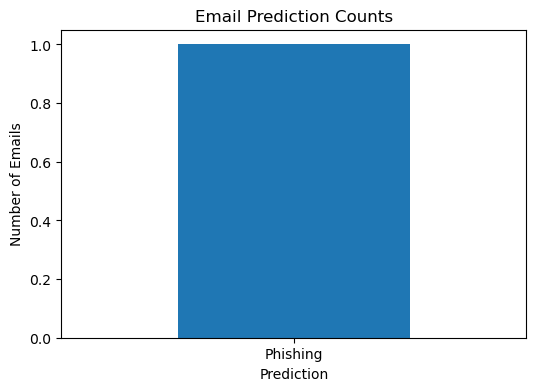

In [40]:
# Bar chart for prediction counts

prediction_counts = logs["prediction"].value_counts()

plt.figure(figsize=(6, 4))
prediction_counts.plot(kind="bar")
plt.title("Email Prediction Counts")
plt.xlabel("Prediction")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

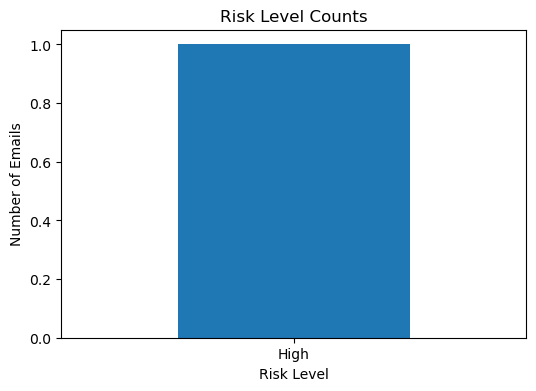

In [41]:
# Bar chart for risk level counts

risk_counts = logs["risk_level"].value_counts()

plt.figure(figsize=(6, 4))
risk_counts.plot(kind="bar")
plt.title("Risk Level Counts")
plt.xlabel("Risk Level")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()